# From Words to Vectors: SVD and Autoencoders on Text

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import umap
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

---
## What are we doing today?

In the previous lectures you learned how to measure **distances** between data points and how to find **clusters** of similar ones. But there's a problem: when data has thousands of dimensions (like text), distances become unreliable and clusters get messy.

Today's lecture is about **compression** — taking something big and squeezing it into something small while keeping the important information. We'll see three ways to do this, each one building on the previous:

1. **SVD** — a linear method that finds "hidden topics" in text
2. **Autoencoders** — a neural network that learns non-linear compression
3. **Pre-trained models (Hugging Face)** — autoencoders trained on billions of sentences

By the end, you'll understand what happens inside tools like sentence embeddings, why they work, and how they connect to everything else in this course.

---
## The data: internet forum posts

We use **20 Newsgroups** — a dataset of posts from internet forums in the 1990s. We pick 5 topics that cover different areas, so we can check whether our compression methods find them.

In [6]:
categories = [
    'rec.sport.baseball',
    'sci.med',
    'comp.graphics',
    'talk.politics.mideast',
    'rec.autos',
]

short_names = {
    'rec.sport.baseball': 'Baseball',
    'sci.med': 'Medicine',
    'comp.graphics': 'Graphics',
    'talk.politics.mideast': 'Politics',
    'rec.autos': 'Cars',
}

data = fetch_20newsgroups(subset='all', categories=categories,
                          remove=('headers', 'footers', 'quotes'),
                          random_state=42)

docs = data.data
labels = data.target
label_names = [short_names[data.target_names[i]] for i in labels]

print(f"Documents: {len(docs)}")
for i, cat in enumerate(data.target_names):
    n = (labels == i).sum()
    print(f"  {short_names[cat]:<12s} {n} posts")
    
print(f"\nExample post ({label_names[0]}):")
print("-" * 50)
print(docs[0][:300])

Documents: 4887
  Graphics     973 posts
  Cars         990 posts
  Baseball     994 posts
  Medicine     990 posts
  Politics     940 posts

Example post (Cars):
--------------------------------------------------
released

here we go again...
now these are just rumors.. so dont quote me.

New Integra supposedly wedge shaped again.  175 hp and all-wheel drive
in top models.  Then a variant called the zx-r comes later. (roadster?).

i think it gets unveiled at end of summer.


---
## Turning text into numbers: TF-IDF

After TF-IDF, each document becomes a vector of numbers — one number per word in the vocabulary. If our vocabulary has 5000 words, each document is a point in a 5000-dimensional space.

In [7]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english',
                        min_df=5, max_df=0.5)
X = tfidf.fit_transform(docs)
words = tfidf.get_feature_names_out()

print(f"Result: {X.shape[0]} documents × {X.shape[1]} words")
print(f"Sparsity: {1 - X.nnz / (X.shape[0] * X.shape[1]):.1%} of cells are zero")
print(f"  → a typical document uses only {X.nnz / X.shape[0]:.0f} of the {X.shape[1]} words")

Result: 4887 documents × 5000 words
Sparsity: 99.0% of cells are zero
  → a typical document uses only 48 of the 5000 words


This matrix is huge and almost entirely empty. Each document uses maybe 100 out of 5000 words. Computing distances directly on this matrix is wasteful — most of those 5000 dimensions contain zero information for any given document. We need to **compress**.

---
## SVD: finding hidden topics

> **Definition.** **SVD** (Singular Value Decomposition) takes a big matrix and decomposes it into a small number of **components**. Each component is a "topic" — a pattern of words that tend to appear together across documents. When applied to a document-word matrix, this is called **Latent Semantic Analysis (LSA)**.

### What SVD does (no formulas needed)

Think of it this way. You have a table: rows are documents, columns are words, cells are TF-IDF scores. SVD looks at this table and notices:

- *"Hmm, whenever 'pitcher' appears, 'batting' and 'innings' also tend to appear..."*
- *"And whenever 'patient' appears, 'diagnosis' and 'treatment' show up too..."*

SVD groups these co-occurring words into **topics**. It doesn't know that the first topic is "baseball" — it just sees the pattern. Each document is then described as a **mix of topics** instead of a list of 5000 individual words.

This is compression: from 5000 numbers (one per word) to, say, 20 numbers (one per topic).

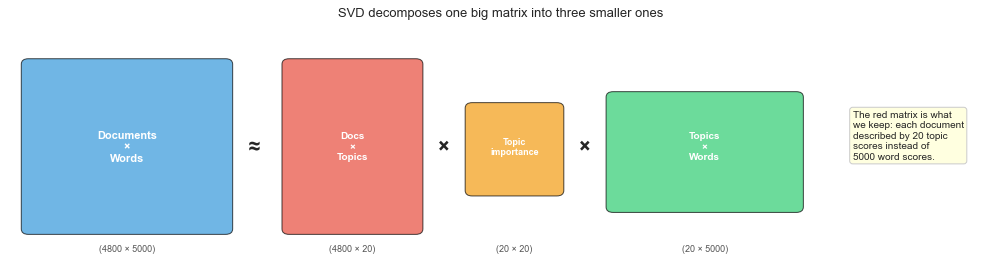

In [8]:
# ── How SVD decomposes the matrix ──

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14); ax.set_ylim(0, 4.5)
ax.axis('off')

# Original matrix
ax.add_patch(mpatches.FancyBboxPatch((0.3, 0.8), 2.8, 3, boxstyle="round,pad=0.1",
             facecolor='#3498db', edgecolor='black', alpha=0.7))
ax.text(1.7, 2.3, 'Documents\n×\nWords', ha='center', va='center',
        fontsize=11, color='white', fontweight='bold')
ax.text(1.7, 0.4, '(4800 × 5000)', ha='center', fontsize=9, color='#555')

ax.text(3.5, 2.3, '≈', fontsize=20, ha='center', va='center', fontweight='bold')

# Documents × Topics
ax.add_patch(mpatches.FancyBboxPatch((4, 0.8), 1.8, 3, boxstyle="round,pad=0.1",
             facecolor='#e74c3c', edgecolor='black', alpha=0.7))
ax.text(4.9, 2.3, 'Docs\n×\nTopics', ha='center', va='center',
        fontsize=10, color='white', fontweight='bold')
ax.text(4.9, 0.4, '(4800 × 20)', ha='center', fontsize=9, color='#555')

ax.text(6.2, 2.3, '×', fontsize=20, ha='center', va='center', fontweight='bold')

# Topic importance
ax.add_patch(mpatches.FancyBboxPatch((6.6, 1.5), 1.2, 1.5, boxstyle="round,pad=0.1",
             facecolor='#f39c12', edgecolor='black', alpha=0.7))
ax.text(7.2, 2.3, 'Topic\nimportance', ha='center', va='center',
        fontsize=9, color='white', fontweight='bold')
ax.text(7.2, 0.4, '(20 × 20)', ha='center', fontsize=9, color='#555')

ax.text(8.2, 2.3, '×', fontsize=20, ha='center', va='center', fontweight='bold')

# Topics × Words
ax.add_patch(mpatches.FancyBboxPatch((8.6, 1.2), 2.6, 2, boxstyle="round,pad=0.1",
             facecolor='#2ecc71', edgecolor='black', alpha=0.7))
ax.text(9.9, 2.3, 'Topics\n×\nWords', ha='center', va='center',
        fontsize=10, color='white', fontweight='bold')
ax.text(9.9, 0.4, '(20 × 5000)', ha='center', fontsize=9, color='#555')

# Annotation
ax.text(12, 2.5, 'The red matrix is what\nwe keep: each document\ndescribed by 20 topic\nscores instead of\n5000 word scores.',
        fontsize=10, ha='left', va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='#ccc'))

plt.title('SVD decomposes one big matrix into three smaller ones', fontsize=13, pad=10)
plt.tight_layout(); plt.show()

### How many topics do we need?

In [9]:
dims = [2, 5, 10, 20, 50, 100]

for d in dims:
    svd = TruncatedSVD(n_components=d, random_state=42)
    X_reduced = svd.fit_transform(X)
    explained = svd.explained_variance_ratio_.sum() * 100
    print(f"  d={d:3d} topics → explains {explained:5.1f}% of variance   "
          f"(compressed from {X.shape[1]} to {d} numbers per document)")

  d=  2 topics → explains   1.1% of variance   (compressed from 5000 to 2 numbers per document)
  d=  5 topics → explains   2.8% of variance   (compressed from 5000 to 5 numbers per document)
  d= 10 topics → explains   4.5% of variance   (compressed from 5000 to 10 numbers per document)
  d= 20 topics → explains   6.7% of variance   (compressed from 5000 to 20 numbers per document)
  d= 50 topics → explains  11.8% of variance   (compressed from 5000 to 50 numbers per document)
  d=100 topics → explains  18.4% of variance   (compressed from 5000 to 100 numbers per document)


These percentages look low — 20 topics explain only ~7% of the total variance. But this is normal and expected for text data. The TF-IDF matrix has 5000 columns and is 99% zeros: the variance is scattered across thousands of tiny directions, most of which are noise (rare words, typos, formatting artifacts).

What matters is not how much *total* variance SVD captures, but whether it captures the **useful structure**. And it does — as we'll see in the next plots, 20 topics are enough to clearly separate the five categories. The ~7% that SVD keeps is the signal; the ~93% it throws away is mostly noise.

### What are these topics?

In [10]:
svd_20 = TruncatedSVD(n_components=20, random_state=42)
X_svd = svd_20.fit_transform(X)

n_top = 8
print(f"{'Topic':<8s}  Top words")
print("-" * 70)
for i in range(10):
    top_idx = svd_20.components_[i].argsort()[::-1][:n_top]
    top_words = [words[j] for j in top_idx]
    print(f"Topic {i:<3d}  {', '.join(top_words)}")

Topic     Top words
----------------------------------------------------------------------
Topic 0    know, don, like, just, think, people, car, does
Topic 1    geb, dsl, cadre, n3jxp, chastity, skepticism, intellect, pitt
Topic 2    israel, armenian, armenians, jews, people, turkish, israeli, jewish
Topic 3    graphics, thanks, armenian, image, israel, file, files, armenians
Topic 4    car, cars, engine, dealer, new, ford, oil, miles
Topic 5    armenian, armenians, turkish, genocide, armenia, turkey, turks, soviet
Topic 6    msg, food, doctor, know, people, don, just, disease
Topic 7    thanks, know, does, advance, mail, info, list, anybody
Topic 8    know, does, don, files, file, format, just, think
Topic 9    think, just, graphics, edu, don, list, people, group


Some topics are immediately recognisable (baseball words, medical words, car words). Others are less clear — they might capture writing style or overlap between categories. SVD found these patterns without ever seeing the labels. It just looked at which words tend to co-occur.

### Visualising documents in topic space

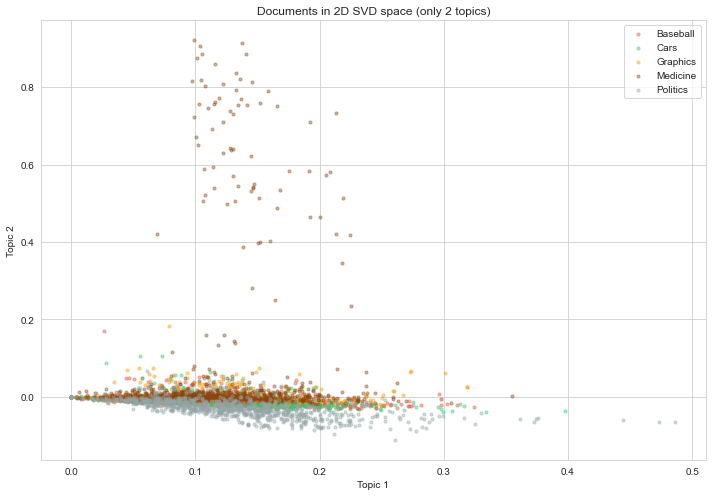

In [11]:
# 2D: SVD directly with 2 components
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X)

unique_labels = sorted(set(label_names))
colors = {'Baseball': '#e74c3c', 'Cars': '#2ecc71', 'Graphics': '#f39c12',
          'Medicine': '#8B4513', 'Politics': '#95a5a6'}

fig, ax = plt.subplots(figsize=(10, 7))
for name in unique_labels:
    mask = np.array(label_names) == name
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[name], s=10, alpha=0.4, label=name)
ax.set_xlabel('Topic 1'); ax.set_ylabel('Topic 2')
ax.set_title('Documents in 2D SVD space (only 2 topics)')
ax.legend()
plt.tight_layout(); plt.show()

With only 2 topics, the categories overlap heavily — two numbers are not enough to distinguish five topics. But we can use UMAP to project the 20-topic vectors into 2D for visualisation:

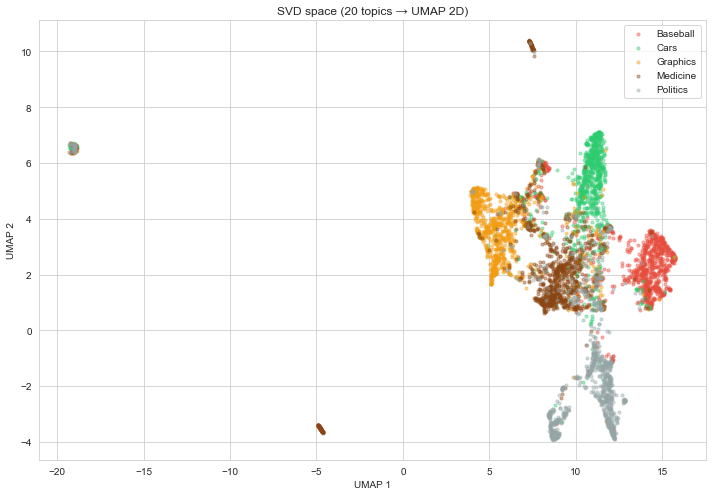

In [12]:
reducer = umap.UMAP(n_components=2, n_neighbors=40, min_dist=0.1, random_state=42, metric='cosine')
X_umap = reducer.fit_transform(X_svd)

fig, ax = plt.subplots(figsize=(10, 7))
for name in unique_labels:
    mask = np.array(label_names) == name
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=colors[name], s=10, alpha=0.4, label=name)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('SVD space (20 topics → UMAP 2D)')
ax.legend()
plt.tight_layout(); plt.show()

**Tuning UMAP for text data.** Three parameters make the biggest difference:

- **`min_dist=0.1`** (or even `0.05`) — makes clusters tighter and more separated. With `0.3` points stay too spread out.
- **`metric='cosine'`** — much better than the default Euclidean distance for TF-IDF and text data, because what matters is the *angle* between vectors, not their magnitude.
- **`n_neighbors=30`** — with 15, UMAP captures too many local details and fragments the groups. Values in the 25–50 range give cleaner clusters.

Much better. The five categories form recognisable groups. SVD compressed 5000 word-dimensions into 20 topic-dimensions, and UMAP reveals that the structure survived.

### Finding similar documents in SVD space

In [13]:
sample_idx = 42
sample_label = label_names[sample_idx]

print(f"SAMPLE DOCUMENT (category: {sample_label})")
print("-" * 60)
print(docs[sample_idx][:500])
print("..." if len(docs[sample_idx]) > 500 else "")

# Nearest neighbours in 20D SVD space
sims = cosine_similarity(X_svd[sample_idx:sample_idx+1], X_svd)[0]
sims[sample_idx] = -1
top5 = np.argsort(sims)[::-1][:5]

print(f"\n5 MOST SIMILAR DOCUMENTS (in SVD space):")
for rank, idx in enumerate(top5, 1):
    print(f"  {rank}. [{label_names[idx]}] sim={sims[idx]:.3f}")
    print(f"     {docs[idx][:120].strip()}...")
    print()

SAMPLE DOCUMENT (category: Baseball)
------------------------------------------------------------
I just wanted to let everyone know that I have lost what little respect I have
for Jim LeFebvre after seeing today's Cubs game. First of all how could he
start Maldonado over May. After the way May played at the end of last year and
the way he tore up the Cactus League how could you let him sit the bench? Not
to mention that a right hander (Maddux) started. I really blew my top when
Lefebvre pinch hit for Rick Wilkins with TOMMY SHIELDS! How can you do that
just because of the lefty-righty thing
...

5 MOST SIMILAR DOCUMENTS (in SVD space):
  1. [Baseball] sim=0.928
     Since I was the one responsible for these divergent threads of
approx. 40+ posts (going back to: The Braves could be bet...

  2. [Baseball] sim=0.916
     Did anyone notice the words "NOT FOR BASEBALL" printed on the picture
of Joe Robbie Stadium in the Opening Day season pr...

  3. [Baseball] sim=0.907
     Most of the 

The neighbours are mostly from the same category — the 20-topic representation is enough to find related documents. But SVD has a limitation: it's **linear**. It can only combine words in straight-line mixtures. It cannot capture context — for example, "car" + "bomb" means something very different from "car" + "engine", but SVD treats "car" the same way in both.

---
## Autoencoders: non-linear compression

> **Definition.** An **autoencoder** is a neural network that learns to copy its input, but is forced to squeeze everything through a narrow **bottleneck** in the middle. The first half (the **encoder**) compresses the input into a small vector. The second half (the **decoder**) tries to reconstruct the original from that small vector.

The bottleneck forces the network to learn what information matters. It can't memorise everything — there isn't room — so it has to figure out the essential structure.

The difference from SVD: the encoder and decoder use **non-linear** operations (ReLU activations), so they can learn curved, complex relationships — not just straight-line topic mixtures.

<img src="https://contenthub-static.grammarly.com/blog/wp-content/uploads/2024/10/6303_blog-visuals-auto-encoders_1500X800.png" width="800">

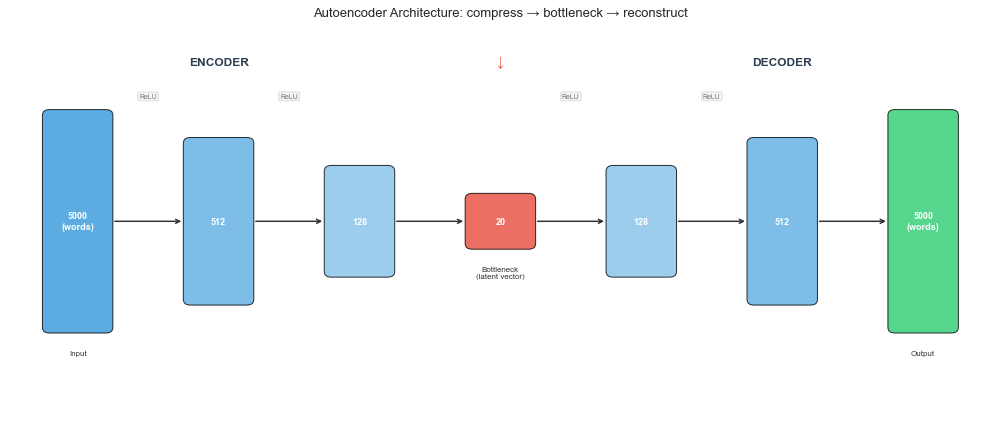

In [14]:
# ── Autoencoder architecture diagram ──

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14); ax.set_ylim(0, 7)
ax.axis('off')

# Layer sizes (visual heights)
layers = [
    (1,   3.5, 3.8, '5000\n(words)',     '#3498db', 'Input'),
    (3,   3.5, 2.8, '512',               '#5dade2', ''),
    (5,   3.5, 1.8, '128',               '#85c1e9', ''),
    (7,   3.5, 0.8, '20',                '#e74c3c', 'Bottleneck\n(latent vector)'),
    (9,   3.5, 1.8, '128',               '#85c1e9', ''),
    (11,  3.5, 2.8, '5dade2',            '#5dade2', ''),
    (13,  3.5, 3.8, '5000\n(words)',     '#2ecc71', 'Output'),
]

# Fix the "5dade2" typo above — use correct label
layers[5] = (11, 3.5, 2.8, '512', '#5dade2', '')

for x, cy, h, label, color, note in layers:
    y0 = cy - h/2
    ax.add_patch(mpatches.FancyBboxPatch((x-0.4, y0), 0.8, h,
                 boxstyle="round,pad=0.1", facecolor=color, edgecolor='black', alpha=0.8))
    ax.text(x, cy, label, ha='center', va='center', fontsize=9,
            color='white', fontweight='bold')
    if note:
        ax.text(x, y0 - 0.4, note, ha='center', va='top', fontsize=8, color='#333')

# Arrows
for i in range(len(layers)-1):
    ax.annotate('', xy=(layers[i+1][0]-0.5, layers[i+1][1]),
                xytext=(layers[i][0]+0.5, layers[i][1]),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#333'))

# Labels
ax.text(3, 6.3, 'ENCODER', ha='center', fontsize=12, fontweight='bold', color='#2c3e50')
ax.text(11, 6.3, 'DECODER', ha='center', fontsize=12, fontweight='bold', color='#2c3e50')
ax.text(7, 6.3, '↓', ha='center', fontsize=14, color='#e74c3c')

# ReLU annotations
for x in [2, 4, 8, 10]:
    ax.text(x, 5.7, 'ReLU', ha='center', fontsize=7, color='#777',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#f5f5f5', edgecolor='#ddd'))

plt.title('Autoencoder Architecture: compress → bottleneck → reconstruct', fontsize=13, pad=10)
plt.tight_layout(); plt.show()

### What is ReLU?

> **Definition.** **ReLU** (Rectified Linear Unit) is the simplest non-linear function: `ReLU(x) = max(0, x)`. If the number is positive, keep it. If negative, set it to zero.

Why does this matter? Without ReLU, stacking linear layers is equivalent to having one big linear layer — you end up with SVD. Adding ReLU between layers allows the network to learn **curves and boundaries** that linear methods cannot. This is the entire reason autoencoders can do better than SVD.

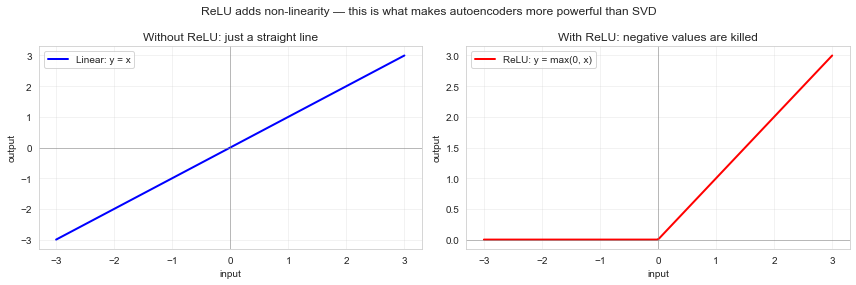

In [15]:
# ── ReLU visualisation ──

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(-3, 3, 200)

axes[0].plot(x, x, 'b-', lw=2, label='Linear: y = x')
axes[0].set_title('Without ReLU: just a straight line'); axes[0].legend()
axes[0].set_xlabel('input'); axes[0].set_ylabel('output')
axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, np.maximum(0, x), 'r-', lw=2, label='ReLU: y = max(0, x)')
axes[1].set_title('With ReLU: negative values are killed'); axes[1].legend()
axes[1].set_xlabel('input'); axes[1].set_ylabel('output')
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ReLU adds non-linearity — this is what makes autoencoders more powerful than SVD',
             fontsize=12)
plt.tight_layout(); plt.show()

### Building and training the autoencoder

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Convert TF-IDF to dense tensor
X_dense = X.toarray().astype(np.float32)
X_tensor = torch.tensor(X_dense)

# Train/test split
n_train = int(0.8 * len(X_dense))
X_train_t = X_tensor[:n_train]
X_test_t  = X_tensor[n_train:]
test_labels = [label_names[i] for i in range(n_train, len(label_names))]

print(f"Train: {X_train_t.shape}  |  Test: {X_test_t.shape}")

Using: cpu
Train: torch.Size([3909, 5000])  |  Test: torch.Size([978, 5000])


In [17]:
class TextAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),  nn.ReLU(),   # 5000 → 512
            nn.Linear(512, 128),        nn.ReLU(),   # 512  → 128
            nn.Linear(128, latent_dim),               # 128  → bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),   # bottleneck → 128
            nn.Linear(128, 512),        nn.ReLU(),   # 128 → 512
            nn.Linear(512, input_dim),  nn.ReLU(),   # 512 → 5000 (ReLU because TF-IDF ≥ 0)
        )
    
    def forward(self, x):
        z = self.encoder(x)          # compress
        return self.decoder(z), z    # reconstruct, also return latent vector

def train_ae(model, X_train, epochs=50, lr=1e-3, batch_size=128):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
    
    history = []
    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            batch = batch.to(device)
            recon, _ = model(batch)
            loss = nn.MSELoss()(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch)
        history.append(total_loss / len(X_train))
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  loss = {history[-1]:.6f}")
    return history

In [18]:
print("Training autoencoder (d=20)...")
ae_20 = TextAutoencoder(X_dense.shape[1], latent_dim=20)
hist_20 = train_ae(ae_20, X_train_t, epochs=50)

print("\nTraining autoencoder (d=2)...")
ae_2 = TextAutoencoder(X_dense.shape[1], latent_dim=2)
hist_2 = train_ae(ae_2, X_train_t, epochs=50)

Training autoencoder (d=20)...
  Epoch  10  loss = 0.000191
  Epoch  20  loss = 0.000190
  Epoch  30  loss = 0.000189
  Epoch  40  loss = 0.000189
  Epoch  50  loss = 0.000189

Training autoencoder (d=2)...
  Epoch  10  loss = 0.000191
  Epoch  20  loss = 0.000191
  Epoch  30  loss = 0.000191
  Epoch  40  loss = 0.000191
  Epoch  50  loss = 0.000191


The d=2 autoencoder has higher loss — squeezing 5000 dimensions into just 2 numbers loses more information. But it still learns *something* useful, as we'll see.

### SVD vs Autoencoder: which separates topics better?

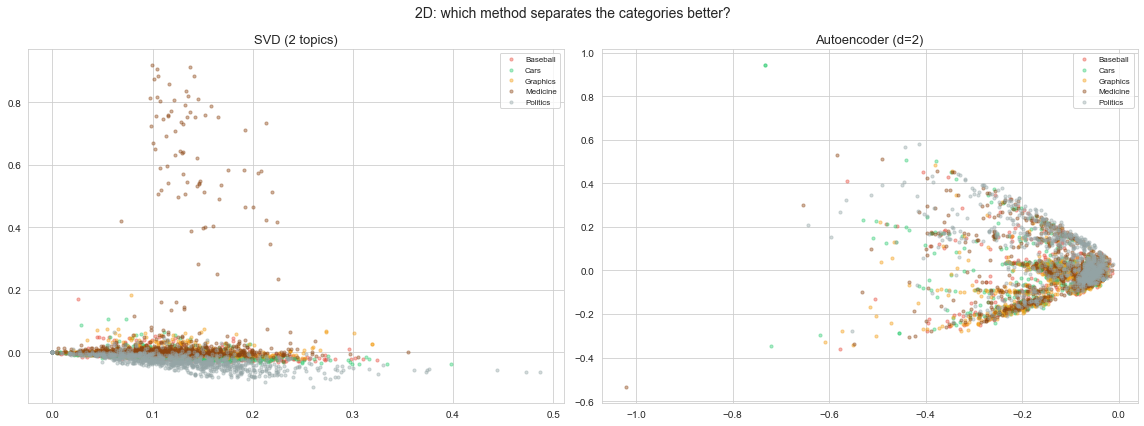

In [20]:
# Extract latent vectors
ae_2.eval(); ae_20.eval()

with torch.no_grad():
    _, z_ae_2d  = ae_2(X_tensor.to(device))
    _, z_ae_20d = ae_20(X_tensor.to(device))
    z_ae_2d  = z_ae_2d.cpu().numpy()
    z_ae_20d = z_ae_20d.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, coords, method in [(axes[0], X_2d, 'SVD (2 topics)'),
                             (axes[1], z_ae_2d, 'Autoencoder (d=2)')]:
    for name in unique_labels:
        mask = np.array(label_names) == name
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=colors[name], s=10, alpha=0.4, label=name)
    ax.set_title(method, fontsize=13)
    ax.legend(fontsize=8)

plt.suptitle('2D: which method separates the categories better?', fontsize=14)
plt.tight_layout(); plt.show()

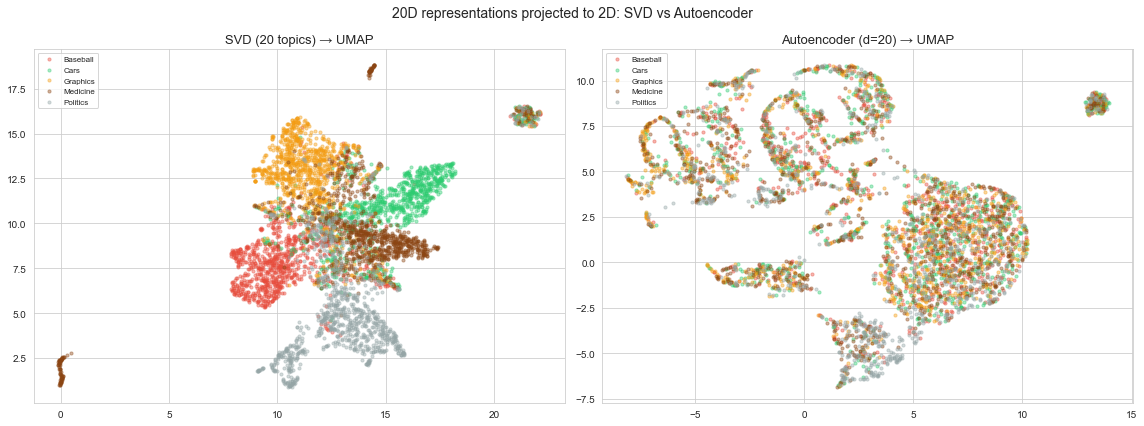

In [21]:
# 20D representations → UMAP 2D
umap_svd = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.3, random_state=42)
umap_ae  = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.3, random_state=42)
Z_svd_2d = umap_svd.fit_transform(X_svd)
Z_ae_2d  = umap_ae.fit_transform(z_ae_20d)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, coords, method in [(axes[0], Z_svd_2d, 'SVD (20 topics) → UMAP'),
                             (axes[1], Z_ae_2d, 'Autoencoder (d=20) → UMAP')]:
    for name in unique_labels:
        mask = np.array(label_names) == name
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=colors[name], s=10, alpha=0.4, label=name)
    ax.set_title(method, fontsize=13)
    ax.legend(fontsize=8)

plt.suptitle('20D representations projected to 2D: SVD vs Autoencoder', fontsize=14)
plt.tight_layout(); plt.show()

In this case, SVD actually produces cleaner clusters than the autoencoder. This is common when:
- The dataset is small (~5000 documents is not much for a neural network)
- The input is very sparse (TF-IDF is 99% zeros — hard for autoencoders)
- SVD finds the optimal linear solution directly, while the autoencoder has to *learn* it from data

This is an important lesson: **more complex ≠ always better**. The autoencoder has more expressive power in theory, but it needs enough data to use it. On small, sparse text data, SVD often wins.

The situation reverses with more data or richer inputs — which is exactly why Transformers models (trained on billions of sentences) outperform both.

### Nearest neighbours: SVD vs Autoencoder

In [22]:
sample_idx = 42

# Neighbours in both spaces
svd_sims = cosine_similarity(X_svd[sample_idx:sample_idx+1], X_svd)[0]
ae_sims  = cosine_similarity(z_ae_20d[sample_idx:sample_idx+1], z_ae_20d)[0]
svd_sims[sample_idx] = -1
ae_sims[sample_idx]  = -1

svd_top5 = np.argsort(svd_sims)[::-1][:5]
ae_top5  = np.argsort(ae_sims)[::-1][:5]

print(f"Query: [{label_names[sample_idx]}] {docs[sample_idx][:80].strip()}...\n")
print(f"{'SVD neighbours':<45s}  {'Autoencoder neighbours'}")
print("-" * 90)
for s, a in zip(svd_top5, ae_top5):
    sl = f"[{label_names[s]}] sim={svd_sims[s]:.3f} {docs[s][:25].strip()}"
    al = f"[{label_names[a]}] sim={ae_sims[a]:.3f} {docs[a][:25].strip()}"
    print(f"{sl:<45s}  {al}")

Query: [Baseball] I just wanted to let everyone know that I have lost what little respect I have
f...

SVD neighbours                                 Autoencoder neighbours
------------------------------------------------------------------------------------------
[Baseball] sim=0.928 Since I was the one respo  [Politics] sim=0.999 (1)

   You know ed,...
[Baseball] sim=0.916 Did anyone notice the wor  [Politics] sim=0.998 It was shafting on the p
[Baseball] sim=0.907 Most of the points you    [Medicine] sim=0.997 Sometimes I have a probl
[Baseball] sim=0.897 Yes - Everyone seems to b  [Cars] sim=0.997 It's great that all these
[Baseball] sim=0.896 Wasn't Hulett injured ye  [Medicine] sim=0.997 I was wondering if a gro


**Takeaway:** a powerful model with too little data is worse than a simple model. SVD wins here because it computes the optimal solution directly. The autoencoder would need much more data — which is exactly why pre-trained models (Hugging Face) exist: someone else already trained on billions of examples.

---
## Denoising autoencoder: learning by filling in the blanks

> **Definition.** A **denoising autoencoder** is trained on corrupted inputs but must reconstruct the clean original. We randomly erase some words from the input and ask the network to guess what's missing.

Why? If the network always sees the complete input, it can memorise surface patterns. If we force it to work with **incomplete** information, it has to learn the *meaning* — which words belong together, what a document is "about" — to fill in the gaps.

This is exactly how modern language models like **BERT** learn. BERT takes a sentence, masks out random words, and trains to predict them. Our denoising autoencoder does the same thing on TF-IDF vectors.

<img src="https://miro.medium.com/v2/resize:fit:1400/1*0uTpozegFTpY0VDNAFgZEg.png" width="700">

In [23]:
def train_denoising(model, X_train, noise_rate=0.3, epochs=50, lr=1e-3, batch_size=128):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
    
    history = []
    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            batch = batch.to(device)
            # Randomly zero out 30% of the input
            mask = (torch.rand_like(batch) > noise_rate).float()
            noisy = batch * mask
            
            recon, _ = model(noisy)
            loss = nn.MSELoss()(recon, batch)   # target is CLEAN
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch)
        history.append(total_loss / len(X_train))
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  loss = {history[-1]:.6f}")
    return history

print("Training denoising autoencoder (d=20)...")
dae = TextAutoencoder(X_dense.shape[1], latent_dim=20)
hist_dae = train_denoising(dae, X_train_t, noise_rate=0.3, epochs=50)

Training denoising autoencoder (d=20)...
  Epoch  10  loss = 0.000191
  Epoch  20  loss = 0.000191
  Epoch  30  loss = 0.000190
  Epoch  40  loss = 0.000190
  Epoch  50  loss = 0.000190


In [24]:
# Show what the denoising AE recovers
dae.eval(); ae_20.eval()

test_idx = sample_idx
original = X_tensor[test_idx:test_idx+1].to(device)

torch.manual_seed(0)
mask = (torch.rand_like(original) > 0.3).float()
corrupted = original * mask

with torch.no_grad():
    recon_standard, _ = ae_20(corrupted)
    recon_denoise, _  = dae(corrupted)

orig_np = original.cpu().numpy().flatten()
corr_np = corrupted.cpu().numpy().flatten()
std_np  = recon_standard.cpu().numpy().flatten()
den_np  = recon_denoise.cpu().numpy().flatten()

# Words that were erased
dropped = (orig_np > 0) & (corr_np == 0)
dropped_idx = np.where(dropped)[0]

recovery = den_np[dropped_idx]
top_recovered = dropped_idx[np.argsort(recovery)[::-1][:10]]

print(f"Document category: {label_names[test_idx]}")
print(f"Words in original: {(orig_np > 0).sum()}")
print(f"Words erased: {dropped.sum()}")
print(f"\nTop words the DENOISING AE recovered (these were erased from the input):")
print(f"{'Word':<20s} {'Original':<10s} {'Standard AE':<14s} {'Denoising AE'}")
print("-" * 58)
for idx in top_recovered:
    print(f"{words[idx]:<20s} {orig_np[idx]:<10.3f} {std_np[idx]:<14.3f} {den_np[idx]:.3f}")

Document category: Baseball
Words in original: 50
Words erased: 13

Top words the DENOISING AE recovered (these were erased from the input):
Word                 Original   Standard AE    Denoising AE
----------------------------------------------------------
thing                0.096      0.000          0.000
showed               0.133      0.000          0.000
pinch                0.155      0.000          0.000
manager              0.134      0.000          0.000
looked               0.118      0.000          0.000
hitter               0.132      0.000          0.000
hit                  0.218      0.000          0.000
got                  0.092      0.000          0.000
game                 0.103      0.000          0.000
fan                  0.131      0.000          0.000


The denoising autoencoder recovers the erased words better. It has learned that certain words belong together — if it sees some baseball words, it can predict the others. The standard autoencoder never had to learn this because it always saw the complete input.

**Connection to collaborative filtering:** think of a user-item rating matrix with missing entries. A denoising autoencoder trained on randomly masked ratings learns to fill in the gaps — this is non-linear matrix factorisation, the same idea as SVD but more powerful.

---
## Pre-trained models: what the big labs do at scale

Everything we built today — TF-IDF, SVD, autoencoders — works. But we trained on ~5000 documents with a 5000-word vocabulary. What if you trained a **massive** autoencoder-like model on **billions** of sentences?

That's what **Transformer** models are. Models like `all-MiniLM-L6-v2` (a popular sentence embedding model) are essentially autoencoders that were:
- Trained on hundreds of millions of sentence pairs
- Using Transformer architecture (a very deep, very powerful encoder)
- With a training objective similar to our denoising autoencoder (predict masked words, match similar sentences)

The result: they produce a **384-dimensional vector** for any sentence, and these vectors capture meaning far better than TF-IDF + SVD. Let's see the difference.

In [4]:
# pip install sentence-transformers (run once if needed)
from sentence_transformers import SentenceTransformer

# This model produces 384-dimensional embeddings
# It downloads ~80MB the first time
model_hf = SentenceTransformer('all-MiniLM-L6-v2')

# Encode all documents (this takes ~1-2 minutes)
print("Encoding documents with Hugging Face model...")
# Truncate long docs to speed things up
docs_truncated = [d[:512] for d in docs]
X_hf = model_hf.encode(docs_truncated, show_progress_bar=True, batch_size=64)
X_hf = np.array(X_hf)

print(f"Hugging Face embeddings: {X_hf.shape}")
print(f"  Each document = {X_hf.shape[1]} numbers (vs our 20 from SVD/AE)")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding documents with Hugging Face model...


Batches:   0%|          | 0/77 [00:00<?, ?it/s]

Hugging Face embeddings: (4887, 384)
  Each document = 384 numbers (vs our 20 from SVD/AE)


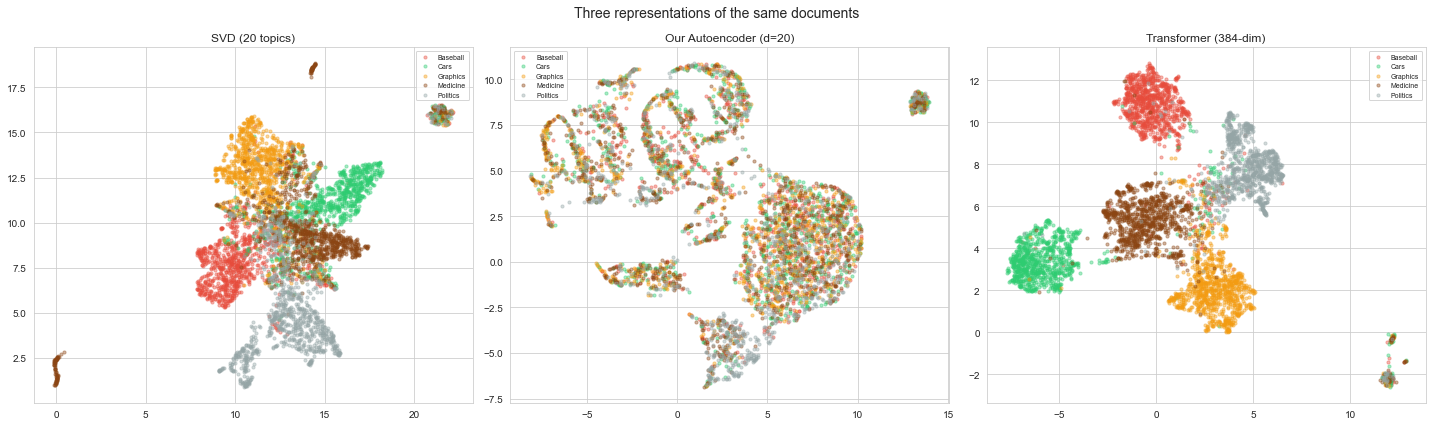

In [25]:
# Compare all three: SVD vs our AE vs Transformer
umap_hf = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.3, random_state=42)
Z_hf_2d = umap_hf.fit_transform(X_hf)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

data_list = [
    (Z_svd_2d, 'SVD (20 topics)'),
    (Z_ae_2d,  'Our Autoencoder (d=20)'),
    (Z_hf_2d,  'Transformer (384-dim)'),
]

for ax, (coords, method) in zip(axes, data_list):
    for name in unique_labels:
        mask = np.array(label_names) == name
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=colors[name], s=10, alpha=0.4, label=name)
    ax.set_title(method, fontsize=12)
    ax.legend(fontsize=7)

plt.suptitle('Three representations of the same documents', fontsize=14)
plt.tight_layout(); plt.show()

Transformer embeddings typically produce the cleanest clusters because they were trained on far more data and understand language at a deeper level. But the point is: **the idea is the same**. A sentence embedding is what you get when you take the autoencoder concept and scale it up with more data, more layers, and smarter training.

In [27]:
# ── Compare nearest neighbours: SVD vs Autoencoder vs HuggingFace ──

# The query document (same one we used before)
print(f"Query document: [{label_names[sample_idx]}]")
print(f"  {docs[sample_idx][:100].strip()}...\n")

# Step 1: compute cosine similarity between the query and ALL documents
#         in each of the three spaces
svd_sims = cosine_similarity(X_svd[sample_idx:sample_idx+1], X_svd)[0]
ae_sims  = cosine_similarity(z_ae_20d[sample_idx:sample_idx+1], z_ae_20d)[0]
hf_sims  = cosine_similarity(X_hf[sample_idx:sample_idx+1], X_hf)[0]

# Step 2: exclude the query itself (otherwise it's always #1 with sim=1.0)
svd_sims[sample_idx] = -1
ae_sims[sample_idx]  = -1
hf_sims[sample_idx]  = -1

# Step 3: find the 5 most similar documents in each space
svd_top5 = np.argsort(svd_sims)[::-1][:5]
ae_top5  = np.argsort(ae_sims)[::-1][:5]
hf_top5  = np.argsort(hf_sims)[::-1][:5]

# Step 4: display side by side
print(f"{'Rank':<6s} {'SVD (20 topics)':<30s} {'Autoencoder (d=20)':<30s} {'HuggingFace (384-dim)'}")
print("-" * 96)
for rank, (s, a, h) in enumerate(zip(svd_top5, ae_top5, hf_top5), 1):
    print(f"{rank:<6d} "
          f"[{label_names[s]:<10s}] sim={svd_sims[s]:.2f}      "
          f"[{label_names[a]:<10s}] sim={ae_sims[a]:.2f}      "
          f"[{label_names[h]:<10s}] sim={hf_sims[h]:.2f}")

Query document: [Baseball]
  I just wanted to let everyone know that I have lost what little respect I have
for Jim LeFebvre afte...

Rank   SVD (20 topics)                Autoencoder (d=20)             HuggingFace (384-dim)
------------------------------------------------------------------------------------------------
1      [Baseball  ] sim=0.93      [Politics  ] sim=1.00      [Baseball  ] sim=0.61
2      [Baseball  ] sim=0.92      [Politics  ] sim=1.00      [Baseball  ] sim=0.51
3      [Baseball  ] sim=0.91      [Medicine  ] sim=1.00      [Baseball  ] sim=0.44
4      [Baseball  ] sim=0.90      [Cars      ] sim=1.00      [Baseball  ] sim=0.43
5      [Baseball  ] sim=0.90      [Medicine  ] sim=1.00      [Baseball  ] sim=0.43


A few things to notice:

- **SVD** finds all correct neighbours with high similarity (~0.90). It works well because the linear topic decomposition is enough to separate these categories.
- **Autoencoder** finds neighbours from wrong categories, all with similarity ≈ 1.00. This means the autoencoder has *collapsed*: it maps every document to nearly the same vector. With only ~5000 documents and a 99%-sparse input, the network doesn't have enough signal to learn meaningful structure.
- **Hugging Face** finds all correct neighbours but with lower scores (~0.4–0.6). The scores are lower because the space has 384 dimensions instead of 20 — in higher-dimensional spaces, cosine similarities are naturally lower. **Do not compare scores across methods** — what matters is whether the ranking is correct.

**Takeaway:** a simple method (SVD) beats a complex one (autoencoder) when data is scarce. A pre-trained model  matches SVD's accuracy here but would vastly outperform it on harder tasks (e.g., finding documents that are semantically similar but use completely different words).